In [6]:
# DECISION TREE AND RANDOM FOREST CLASSIFICATION
# STUDENT PLACEMENT DATASET

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('/content/Student_Placement_Skills_2025.csv')

# Drop missing values
df = df.dropna()

# Encode categorical columns
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = LabelEncoder().fit_transform(df[column])

# The problem states 'Placement status' as the target, but 'Salary_Offered_USD' is continuous.
# To perform classification, we will convert 'Salary_Offered_USD' into a binary 'Placement_Status'.
# For simplicity, we'll classify a student as 'Placed' (1) if their salary is above the median,
# and 'Not Placed' (0) if it's at or below the median.
df['Placement_Status'] = (df['Salary_Offered_USD'] > df['Salary_Offered_USD'].median()).astype(int)

# Define features (X) and target (y)
# X includes all columns except 'Salary_Offered_USD' and the newly created 'Placement_Status'
X = df.drop(['Salary_Offered_USD', 'Placement_Status'], axis=1)
y = df['Placement_Status'] # Use the new binary target for classification

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# -----------------------------------
# 1️⃣ Decision Tree Classifier
# -----------------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("DECISION TREE RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("--------------------------------------------------")

# -----------------------------------
# 2️⃣ Random Forest Classifier
# -----------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

DECISION TREE RESULTS
Accuracy: 0.4666666666666667

Confusion Matrix:
 [[35 32]
 [32 21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.52      0.52        67
           1       0.40      0.40      0.40        53

    accuracy                           0.47       120
   macro avg       0.46      0.46      0.46       120
weighted avg       0.47      0.47      0.47       120

--------------------------------------------------
RANDOM FOREST RESULTS
Accuracy: 0.48333333333333334

Confusion Matrix:
 [[30 37]
 [25 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.45      0.49        67
           1       0.43      0.53      0.47        53

    accuracy                           0.48       120
   macro avg       0.49      0.49      0.48       120
weighted avg       0.49      0.48      0.48       120



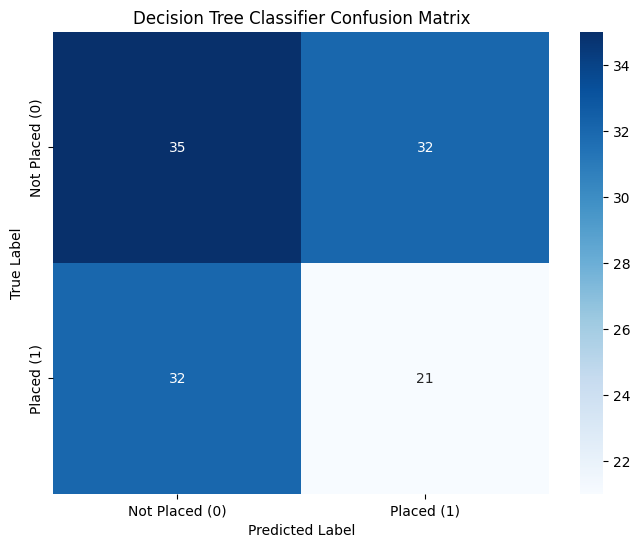

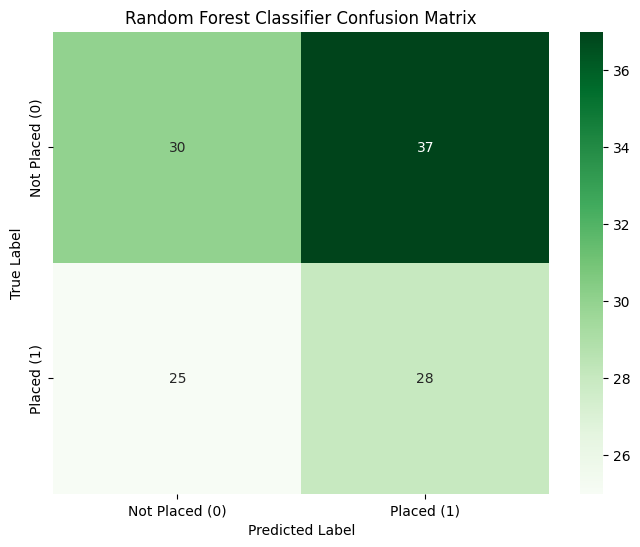

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Confusion Matrix for Decision Tree ---
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed (0)', 'Placed (1)'], yticklabels=['Not Placed (0)', 'Placed (1)'])
plt.title('Decision Tree Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Confusion Matrix for Random Forest ---
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Placed (0)', 'Placed (1)'], yticklabels=['Not Placed (0)', 'Placed (1)'])
plt.title('Random Forest Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()